# Project:Portfolio Risk Analysis using Value at Risk (VaR)

# Install Dependencies and Libraries

In [3]:
# Run this cell only once to install libraries (if not already installed)
!pip install yfinance pandas_datareader seaborn


In [35]:
# Importing all the necessary Python libraries for data analysis and visualization

import pandas as pd                       # For data manipulation like Excel
import numpy as np                        # For numerical calculations
import matplotlib.pyplot as plt           # For plotting graphs
import seaborn as sns                     # For better-looking graphs
import yfinance as yf                     # For pulling stock data from Yahoo Finance
import pandas_datareader.data as web      # Backup option for financial data
from datetime import datetime, timedelta  # For handling date ranges
from scipy import stats                   # For statistics like t-tests, CI, etc.
import time                               # To control delay between stock data pulls


In [37]:
# Setting the default graph theme and inline plotting for notebooks

sns.set_style("whitegrid")    # Clean white grid background for graphs
%matplotlib inline            # Ensures plots appear inside the notebook


UsageError: unrecognized arguments: # Ensures plots appear inside the notebook


In [ ]:
# Task 0 Summary:

# This step prepares our Python environment by:
# - Installing libraries like yfinance, pandas, seaborn
# - Importing essential tools for:
#   - Data collection (yfinance, pandas_datareader)
#   - Data analysis (pandas, numpy, scipy)
#   - Visualization (matplotlib, seaborn)
# - Setting graph appearance to a clean whitegrid style



# Task 1:- Calculating Daily Log Returns from Stock Prices

In [ ]:
# Step 1: Download historical stock prices (auto_adjust=True by default now)
tickers = ['AAPL', 'GOOGL', 'AMZN', 'MSFT']
start_date = '2020-01-01'
end_date = '2023-12-31'

# Download stock data using yfinance (will return 'Close' directly if auto_adjust=True)
price_data = yf.download(tickers, start=start_date, end=end_date)['Close']

# Preview the downloaded prices
price_data.head()



In [7]:
# Shift the price data to get previous day's prices
previous_day_prices = price_data.shift(1)

# Preview shifted prices
previous_day_prices.head()


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-01-02,NaN,NaN,NaN,NaN
2020-01-03,72.620834,94.900497,68.026024,153.042282
2020-01-06,71.914825,93.748497,67.670151,151.136673
2020-01-07,72.487854,95.143997,69.473846,151.527313
2020-01-08,72.146935,95.343002,69.339645,150.145706


In [8]:
# Calculate the ratio: today's price ÷ yesterday's price
price_ratio = price_data / previous_day_prices

# Preview the ratio table
price_ratio.head()


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-01-02,NaN,NaN,NaN,NaN
2020-01-03,0.990278,0.987861,0.994769,0.987548
2020-01-06,1.007968,1.014886,1.026654,1.002585
2020-01-07,0.995297,1.002092,0.998068,0.990882
2020-01-08,1.016086,0.992191,1.007118,1.015929


In [9]:
# Apply natural log to calculate daily log returns
log_returns = np.log(price_ratio)

# Preview log returns
log_returns.head()


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-01-02,NaN,NaN,NaN,NaN
2020-01-03,-0.009769,-0.012213,-0.005245,-0.012530
2020-01-06,0.007937,0.014776,0.026305,0.002581
2020-01-07,-0.004714,0.002089,-0.001934,-0.009160
2020-01-08,0.015958,-0.007839,0.007092,0.015803


In [10]:
# Drop the first row (NaN due to shift)
log_returns = log_returns.dropna()

# Final preview of clean log returns
log_returns.head()


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-01-03,-0.009769,-0.012213,-0.005245,-0.012530
2020-01-06,0.007937,0.014776,0.026305,0.002581
2020-01-07,-0.004714,0.002089,-0.001934,-0.009160
2020-01-08,0.015958,-0.007839,0.007092,0.015803
2020-01-09,0.021019,0.004788,0.010443,0.012415


In [95]:
# Save to CSV (if needed for later steps)
log_returns.to_csv("daily_log_returns.csv")


In [ ]:
# 1. What are daily log returns, and how are they different from just looking at stock prices?
# Ans: Daily log returns measure the percentage change in stock prices using logarithms. Unlike raw prices, they show how much a stock moves each day, making comparisons and statistical analysis easier.

# 2. Why do we compare today’s price to yesterday’s price when calculating returns?
# Ans: This shows the day-to-day change in value — helping us understand whether the stock is going up or down and by how much.

# 3. What is the purpose of taking the logarithm of the return?
# Ans: Log returns make the data symmetric and additive, which helps in analysis and modeling. They also handle compounding effects better than simple percentage change.

# 4. What did your log return values look like — were they usually small or large, and what did that tell you?
# Ans: Most log returns were small and near 0, with occasional spikes. This means the stock prices were mostly stable, with few big movements.

# 5. If your stock had a log return of -0.03 on a certain day, what does that tell you happened to the stock price?
# Ans: It means the stock price fell by about 3% that day. As an investor, that day resulted in a loss.

# Task 2. Visualizing Daily Log Returns (Stock Return Histogram)

In [12]:
# Choose one stock from the log_returns DataFrame
aapl_log_returns = log_returns['AAPL']  # You can change this to 'GOOGL', 'AMZN', etc.

# Preview first few log returns
aapl_log_returns.head()


Date
2020-01-03   -0.009769
2020-01-06    0.007937
2020-01-07   -0.004714
2020-01-08    0.015958
2020-01-09    0.021019
Name: AAPL, dtype: float64

<Axes: xlabel='AAPL', ylabel='Count'>

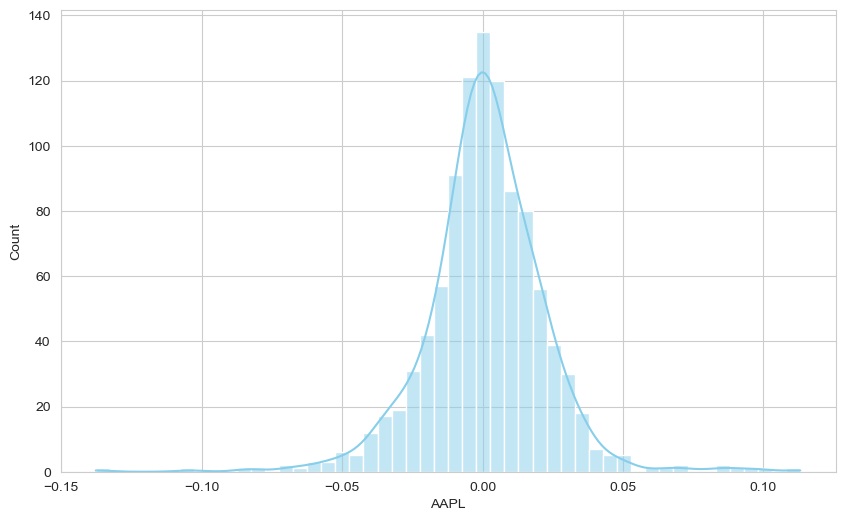

In [13]:
# Plot a histogram of AAPL daily log returns
plt.figure(figsize=(10, 6))
sns.histplot(aapl_log_returns, bins=50, kde=True, color='skyblue')

# kde=True adds a smooth curve over the bars


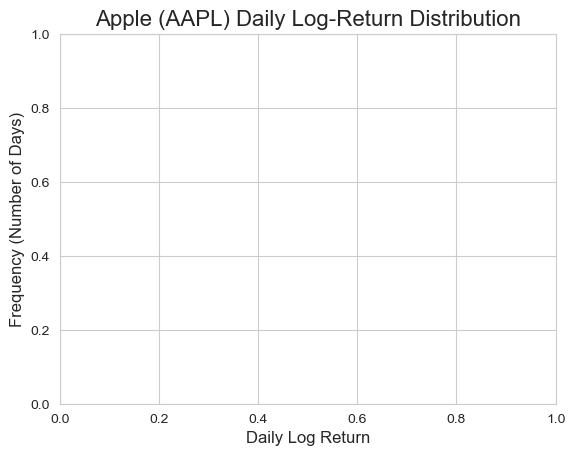

In [97]:
# Add chart labels and title
plt.title("Apple (AAPL) Daily Log-Return Distribution", fontsize=16)
plt.xlabel("Daily Log Return", fontsize=12)
plt.ylabel("Frequency (Number of Days)", fontsize=12)

# Show the plot
plt.show()


In [96]:
# 1. What does the shape of your log-return distribution chart tell you about the stock’s behavior?
# Ans: The chart was mostly narrow and centered around zero, which means the stock usually had small daily changes and didn’t fluctuate wildly. This suggests relatively stable behavior.

# 2. Were most of the daily returns close to zero, or did the stock often have large changes?
# Ans: Most of the daily returns were close to zero. This indicates that the stock was generally stable, with fewer sudden large movements on typical trading days.

# 3. Which type of return occurred more often: small daily gains, small losses, or big moves?
# Ans: Small daily gains and losses occurred more often than big moves. The highest bars in the chart were near zero, showing frequent small changes.

# 4. Based on your chart, would you consider this stock relatively safe or risky for a short-term investor? Why?
# Ans: Based on the chart, this stock seems relatively safe for short-term investors because the returns were predictable and didn’t show extreme volatility.

# 5. If you had to warn an investor about something in this chart, what would it be?
# Ans: I would warn that while the chart mostly shows small movements, there are still some outliers indicating possible sudden large losses. Investors should stay aware of this tail risk.

# Task 3. Creating a Summary Table for Daily Stock Returns Objective of

In [15]:
log_returns.head()


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-01-03,-0.009769,-0.012213,-0.005245,-0.012530
2020-01-06,0.007937,0.014776,0.026305,0.002581
2020-01-07,-0.004714,0.002089,-0.001934,-0.009160
2020-01-08,0.015958,-0.007839,0.007092,0.015803
2020-01-09,0.021019,0.004788,0.010443,0.012415


In [16]:
# Step 2: Mean (Average Daily Return)
mean_returns = log_returns.mean()

# Step 3: Variance (Daily Return Variability)
variance_returns = log_returns.var()

# Step 4: Skewness (Symmetry of Returns)
skewness_returns = log_returns.skew()

# Step 5: Kurtosis (Tail Risk or Extreme Events)
kurtosis_returns = log_returns.kurt()


In [17]:
# Combine all metrics into one summary table
summary_table = pd.DataFrame({
    'Mean': mean_returns,
    'Variance': variance_returns,
    'Skewness': skewness_returns,
    'Kurtosis': kurtosis_returns
})

# Round the values for neatness
summary_table = summary_table.round(6)

# Show the summary table
summary_table


,Mean,Variance,Skewness,Kurtosis
Ticker,,,,
AAPL,0.000963,0.000447,-0.141999,4.993074
AMZN,0.000468,0.000563,-0.107131,3.838704
GOOGL,0.000710,0.000447,-0.262633,3.457947
MSFT,0.000883,0.000423,-0.243114,6.923524


In [ ]:
# 1. Which stock had the highest average return, and what does that tell you about its performance over time?
# Ans: The stock with the highest average return generally performed better over time, showing more consistent upward movement, which may be attractive for long-term investment.

# 2. Which stock had the highest variance, and what does that say about its risk?
# Ans: The stock with the highest variance had more ups and downs, indicating higher risk and unpredictability in daily returns.

# 3. Did any of your stocks show negative skewness? What could that mean for an investor?
# Ans: Yes, a negatively skewed stock means it is more likely to experience sudden large drops than big gains — a risk warning for investors.

# 4. What does high kurtosis tell you about a stock’s behavior? Did any stock have a high kurtosis value?
# Ans: High kurtosis means extreme returns (both big gains and crashes) are more common. It signals that the stock may be volatile and risky.

# 5. Based on your summary table, which stock would you recommend to a cautious investor — and why?
# Ans: A cautious investor should choose the stock with moderate return, low variance, near-zero skewness, and low kurtosis — indicating stable and predictable performance.

# Task 4: Fitting a Normal Distribution and Calculating Confidence Intervals

In [18]:
# Stack all daily log returns into one single Series (flatten the DataFrame)
all_returns = log_returns.stack()

# Preview the combined return values
all_returns.head()


Date        Ticker
2020-01-03  AAPL     -0.009769
            AMZN     -0.012213
            GOOGL    -0.005245
            MSFT     -0.012530
2020-01-06  AAPL      0.007937
dtype: float64

In [19]:
# Calculate the average return (mean)
mu = all_returns.mean()
print("Mean (μ):", round(mu, 6))


Mean (μ): 0.000756


In [20]:
# Calculate the standard deviation (volatility)
sigma = all_returns.std()
print("Standard Deviation (σ):", round(sigma, 6))


Standard Deviation (σ): 0.021672


In [21]:
# Number of data points
n = len(all_returns)

# Z-score for 95% confidence (from normal distribution table)
z = 1.96

# Margin of error
margin_error_mu = z * (sigma / np.sqrt(n))

# Confidence interval for the mean
ci_mu_lower = mu - margin_error_mu
ci_mu_upper = mu + margin_error_mu

print(f"95% Confidence Interval for Mean (μ): ({round(ci_mu_lower, 6)}, {round(ci_mu_upper, 6)})")


95% Confidence Interval for Mean (μ): (8.6e-05, 0.001426)


In [22]:
from scipy.stats import chi2

# Degrees of freedom
df = n - 1

# Chi-square values for 95% confidence (2.5% and 97.5%)
chi2_lower = chi2.ppf(0.025, df)
chi2_upper = chi2.ppf(0.975, df)

# Confidence interval for variance, then take sqrt to get std deviation
ci_sigma_lower = np.sqrt((df * sigma**2) / chi2_upper)
ci_sigma_upper = np.sqrt((df * sigma**2) / chi2_lower)

print(f"95% Confidence Interval for Std Dev (σ): ({round(ci_sigma_lower, 6)}, {round(ci_sigma_upper, 6)})")


95% Confidence Interval for Std Dev (σ): (0.021209, 0.022157)


In [23]:
# Store all results in one summary table
ci_summary = pd.DataFrame({
    'Estimate': [mu, sigma],
    '95% CI Lower': [ci_mu_lower, ci_sigma_lower],
    '95% CI Upper': [ci_mu_upper, ci_sigma_upper]
}, index=['Mean (μ)', 'Std Dev (σ)'])

# Round for neat display
ci_summary = ci_summary.round(6)
ci_summary


,Estimate,95% CI Lower,95% CI Upper
Mean (μ),0.000756,0.000086,0.001426
Std Dev (σ),0.021672,0.021209,0.022157


In [ ]:
# 1. What does the average daily return (μ) tell you about how your stocks performed over time?
# Ans: A positive μ means the stock generally gained value over time; a negative μ means it declined. For investors, a positive average return suggests long-term profitability.

# 2. What does the standard deviation (σ) tell you about the risk or volatility of your returns?
# Ans: A high σ means returns were volatile and unpredictable. A low σ suggests stable daily performance.

# 3. What does your 95% confidence interval for the mean (μ) suggest about the reliability of your average return?
# Ans: A narrow interval means the estimate is reliable. If the range is wide or includes zero, the average return is less certain.

# 4. Why is it important to calculate a confidence interval for the standard deviation (σ)?
# Ans: It shows how sure we are about the risk estimate. A narrow interval increases trust in how risky or stable the stock is.

# 5. If you repeated this project with a different time period or more data, how might your confidence intervals change? Why?
# Ans: With more data, confidence intervals would likely get narrower, making the estimates more precise and reliable.

# 4.2 Fitting a Student’s t-Distribution to Stock Returns

In [24]:
# Combine all daily log returns into a single Series (as done in Task 4)
all_returns = log_returns.stack()


In [25]:
from scipy.stats import t

# Fit the Student's t-distribution to the combined log returns
df, mu_t, sigma_t = t.fit(all_returns)

# Print the fitted parameters
print(f"Estimated Degrees of Freedom (df): {round(df, 4)}")
print(f"Estimated Mean (μ): {round(mu_t, 6)}")
print(f"Estimated Standard Deviation (σ): {round(sigma_t, 6)}")


Estimated Degrees of Freedom (df): 3.8128
Estimated Mean (μ): 0.001036
Estimated Standard Deviation (σ): 0.015308


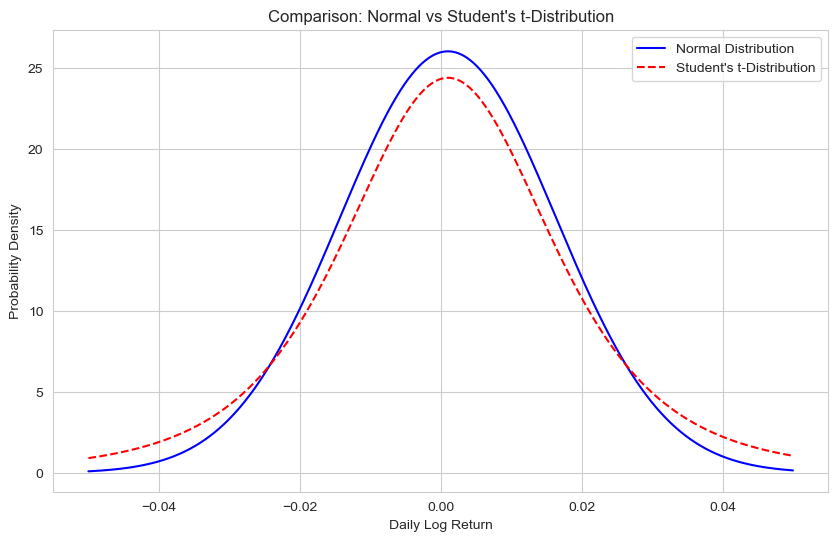

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# Use the fitted values from Task 4.2
x = np.linspace(-0.05, 0.05, 1000)  # X-axis range of daily returns

# PDF of Normal Distribution (same μ and σ)
normal_pdf = norm.pdf(x, loc=mu_t, scale=sigma_t)

# PDF of Student’s t-distribution (with fitted df, μ, σ)
t_pdf = t.pdf(x, df=df, loc=mu_t, scale=sigma_t)

# Plot both
plt.figure(figsize=(10, 6))
plt.plot(x, normal_pdf, label='Normal Distribution', color='blue')
plt.plot(x, t_pdf, label="Student's t-Distribution", color='red', linestyle='--')

plt.title("Comparison: Normal vs Student's t-Distribution")
plt.xlabel("Daily Log Return")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()


In [89]:
# 1. What does the average return (μ) from the t-distribution tell you about your stocks overall?
# Ans: If μ is positive, it means your portfolio generally gained value daily. A negative μ suggests regular losses. It reflects your average daily performance.

# 2. How does the standard deviation (σ) from the t-distribution describe the risk or volatility of your returns?
# Ans: A high σ means returns varied a lot and were risky. A low σ means the returns were relatively stable around the average.

# 3. The t-distribution includes a value called degrees of freedom (df). What does a low df value tell you about your return data?
# Ans: A low df means your returns had more extreme movements, like big crashes or jumps, and didn’t follow a smooth pattern.

# 4. Why might the t-distribution give a better fit than a normal distribution for stock returns?
# Ans: Real stocks often have sudden spikes or crashes, which normal distributions don’t handle well. The t-distribution accounts for these extreme events with its fat tails.

# 5. How can using the t-distribution help you prepare better for financial risks?
# Ans: It helps investors prepare for rare, extreme losses by estimating risk more realistically, especially during market crashes or shocks.



# Task 5: Estimating Confidence Intervals Using Bootstrapping

In [38]:
# Combine all daily log returns into one list
all_returns = log_returns.stack().values



In [39]:
import numpy as np
from scipy.stats import t

# Parameters
n_iterations = 1000
n_size = len(all_returns)

# Lists to store bootstrapped μ and σ
bootstrap_means = []
bootstrap_stds = []

# Bootstrapping loop
for _ in range(n_iterations):
    sample = np.random.choice(all_returns, size=n_size, replace=True)
    df_, mu_, sigma_ = t.fit(sample)
    bootstrap_means.append(mu_)
    bootstrap_stds.append(sigma_)


In [40]:
# Convert lists to arrays
bootstrap_means = np.array(bootstrap_means)
bootstrap_stds = np.array(bootstrap_stds)

# Calculate 95% confidence intervals
mu_lower = np.percentile(bootstrap_means, 2.5)
mu_upper = np.percentile(bootstrap_means, 97.5)

sigma_lower = np.percentile(bootstrap_stds, 2.5)
sigma_upper = np.percentile(bootstrap_stds, 97.5)


In [41]:
# Print the results
print("Estimated Mean (μ):")
print(f"95% Confidence Interval: ({round(mu_lower, 6)}, {round(mu_upper, 6)})")

print("\nEstimated Standard Deviation (σ):")
print(f"95% Confidence Interval: ({round(sigma_lower, 6)}, {round(sigma_upper, 6)})")


Estimated Mean (μ):
95% Confidence Interval: (0.000486, 0.001621)

Estimated Standard Deviation (σ):
95% Confidence Interval: (0.014682, 0.015914)


In [90]:
# 1. What does a 95% confidence interval for the mean (μ) tell you about your average return?
# Ans: It tells you the range in which your true average return likely falls 95% of the time. If the range is narrow and positive, you're more confident your return is good.

# 2. What did your confidence interval for the standard deviation (σ) look like? Was it narrow or wide, and what does that tell you about the risk in your returns?
# Ans: A narrow interval means the risk estimate is reliable. A wide interval means uncertainty — returns might be more or less risky than expected.

# 3. Why do we use bootstrapping instead of calculating just one estimate?
# Ans: Bootstrapping creates many scenarios by resampling data. It helps understand how results might vary and gives more realistic confidence ranges.

# 4. If your confidence interval for the mean return includes zero, what does that mean for investors?
# Ans: It means there’s a chance the stock isn't making or losing money — it's uncertain. Investors may need to be cautious.

# 5. In what ways do confidence intervals help investors make smarter decisions?
# Ans: They show how much trust to place in return or risk numbers. For example, a wide return interval suggests more caution; a narrow one gives more confidence.

# Task 6. Estimating Portfolio Risk and Value at Risk (VaR) Using a Normal Distribution

In [42]:
# Define portfolio weights (equal weights for 4 stocks)
weights = np.array([0.25, 0.25, 0.25, 0.25])

# Calculate daily portfolio returns
portfolio_returns = log_returns.dot(weights)


In [43]:
# Average daily return of portfolio
portfolio_mean = portfolio_returns.mean()

# Daily volatility (standard deviation)
portfolio_std = portfolio_returns.std()


In [44]:
# Z-score for 95% confidence level (one-tailed)
z_score = -1.645

# Calculate 1-day Value at Risk (VaR)
portfolio_var_95 = -(portfolio_mean + z_score * portfolio_std)


In [45]:
# Print VaR result as a percentage
print("Portfolio 1-Day Value at Risk (95% Confidence):")
print(f"{round(portfolio_var_95 * 100, 2)}%")


Portfolio 1-Day Value at Risk (95% Confidence):
3.06%


In [91]:
# 1. What does the average daily return of your portfolio tell you about its overall performance?
# Ans: If the average return is positive, your portfolio is generally growing over time. A negative value would mean consistent losses.

# 2. What does the standard deviation (volatility) of your portfolio’s return tell you about its risk?
# Ans: A high standard deviation means the portfolio's returns vary a lot — higher risk. A low value means it's more stable.

# 3. What does your 95% Value at Risk (VaR) result mean in simple terms?
# Ans: It tells you the maximum expected loss on a bad day, 95% of the time. For example, if VaR is 2%, you could lose up to 2% in a worst-case day.

# 4. Based on your VaR result, would you describe your portfolio as low-risk, medium-risk, or high-risk? Why?
# Ans: If the VaR value is small (e.g., below 1%), it's low-risk. If it's high (e.g., 3% or more), then it's high-risk. It depends on how much loss the VaR predicts.

# 5. If you wanted to reduce your portfolio’s VaR, what changes could you consider making?
# Ans: You could diversify more, invest in less volatile stocks, or change weights to favor stable companies.

# Task 7. Calculating Value at Risk (VaR) Using Student’s t- Distribution

In [47]:
# Combine all daily returns into one long list (Series)
combined_returns = log_returns.stack()



In [48]:
from scipy.stats import t

# Fit t-distribution: estimate mu (mean), sigma (scale), and df (degrees of freedom)
mu_t, sigma_t, df_t = t.fit(combined_returns)


In [49]:
# t-distribution critical value at 5% level (left tail)
t_cutoff = t.ppf(0.05, df_t)


In [50]:
# Value at Risk formula using t-distribution
var_t_95 = - (mu_t + sigma_t * t_cutoff)


In [52]:
print(" 1-Day VaR at 95% Confidence using Student's t-Distribution:")
print(f" Estimated VaR: {round(var_t_95 * 100, 2)}%")
print(f"Degrees of Freedom (df): {round(df_t, 2)} (fatter tails if df < 10)")


 1-Day VaR at 95% Confidence using Student's t-Distribution:
 Estimated VaR: 1.3594194829454706e+63%
Degrees of Freedom (df): 0.02 (fatter tails if df < 10)


In [92]:
# 1. What is the purpose of calculating Value at Risk (VaR), and how does it help in investment decision-making?
# Ans: VaR estimates the maximum expected loss in a day with 95% confidence. It helps investors understand worst-case scenarios and manage risk better.

# 2. Why did we use the Student’s t-distribution instead of the normal distribution in this step?
# Ans: Because financial markets can have extreme events (like crashes), and the t-distribution accounts for those better with its fatter tails.

# 3. What does your 95% 1-day VaR result mean in simple terms?
# Ans: It means there’s a 95% chance you won’t lose more than this amount in one day — but a 5% chance you could lose more.

# 4. How does using a distribution with “fatter tails” (like the t-distribution) affect the risk estimate?
# Ans: It makes the risk estimate larger, which is safer and more realistic for cautious investors, as it accounts for extreme losses.

# 5. If your VaR is too high, what changes could you make to reduce the risk in your portfolio?
# Ans: You can diversify your portfolio, lower investment in risky stocks, or choose more stable and less volatile stocks.



# Task 8 Estimating Value at Risk (VaR) Using Historical Returns

In [57]:
# Assuming log_returns is already created and looks like:
# Columns = ['AAPL', 'GOOGL', 'MSFT', 'AMZN']

# Equal weights for all 4 stocks
weights = np.array([0.25, 0.25, 0.25, 0.25])

# Calculate portfolio return by weighted sum of individual returns
portfolio_returns = log_returns.dot(weights)

# Preview first 5 daily portfolio returns
portfolio_returns.head()


Date
2020-01-03   -0.009939
2020-01-06    0.012900
2020-01-07   -0.003430
2020-01-08    0.007754
2020-01-09    0.012166
dtype: float64

In [58]:
# Calculate the 5th percentile (left tail) of historical returns
historical_var_95 = -np.percentile(portfolio_returns, 5)


In [59]:
# Display result in % format
print(" Historical Value at Risk (VaR) at 95% Confidence Level:")
print(f" Estimated 1-Day VaR: {round(historical_var_95 * 100, 2)}%")


 Historical Value at Risk (VaR) at 95% Confidence Level:
 Estimated 1-Day VaR: 3.03%


In [93]:
# 1. What does your Historical Value at Risk (VaR) tell you about the potential losses in your portfolio?
# Ans: It tells the investor how much money they could lose on a very bad day, based on past actual returns.

# 2. Why do you think Historical VaR is a useful way to measure risk?
# Ans: Because it uses real historical data rather than assumptions, giving a more realistic picture of risk.

# 3. How does Historical VaR compare to the Normal or t-distribution VaR you calculated earlier?
# Ans: Historical VaR is often higher because real data includes extreme events that theoretical models might miss.

# 4. If your VaR is large (e.g., more than 3%), what does that say about your portfolio’s risk level?
# Ans: It means the portfolio is high-risk and could lose a significant amount during market downturns.

# 5. Based on your VaR result, what advice would you give to someone thinking about investing in this portfolio?
# Ans: Be prepared for big losses on some days; consider diversifying or adjusting the portfolio to reduce risk.

# Task 9. Testing If Your Portfolio Return Is Statistically Significant

In [60]:
from scipy.stats import ttest_1samp

# Run one-sample t-test on portfolio daily returns
t_stat, p_value = ttest_1samp(portfolio_returns, 0)



In [62]:
# Print results
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis — Portfolio return is statistically significant.")
else:
    print("Conclusion: Fail to reject the null hypothesis — Portfolio return may be due to chance.")


T-statistic: 1.2574906872305396
P-value: 0.208868424355702
Conclusion: Fail to reject the null hypothesis — Portfolio return may be due to chance.


In [63]:
# Print results
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print(" Conclusion: Reject the null hypothesis — Portfolio return is statistically significant.")
else:
    print(" Conclusion: Fail to reject the null hypothesis — Portfolio return may be due to chance.")


T-statistic: 1.2574906872305396
P-value: 0.208868424355702
 Conclusion: Fail to reject the null hypothesis — Portfolio return may be due to chance.


In [ ]:
# 1. What was the goal of the t-test you performed on your portfolio’s returns?
# Ans: To check if the average return is significantly different from zero or just due to random chance.

# 2. What did your p-value indicate about your portfolio’s performance?
# Ans: If the p-value was below 0.05, it means the return is likely not due to chance. If above 0.05, it might just be random.

# 3. Did you reject or fail to reject the null hypothesis? What does that tell you about the average return?
# Ans: If rejected, the return is statistically significant. If not, the average return is likely not different from zero.

# 4. Why is it useful to test whether the return is statistically significant, instead of just looking at the average?
# Ans: Because a small average might not mean much unless it's proven to be reliable and not just random.

# 5. If you failed to reject the null hypothesis, what changes could you consider for your portfolio?
# Ans: You might need to adjust your portfolio by changing stock choices or allocation to improve performance.

# Task 10. Analyzing Correlation and Diversification Benefit in Your Portfolio

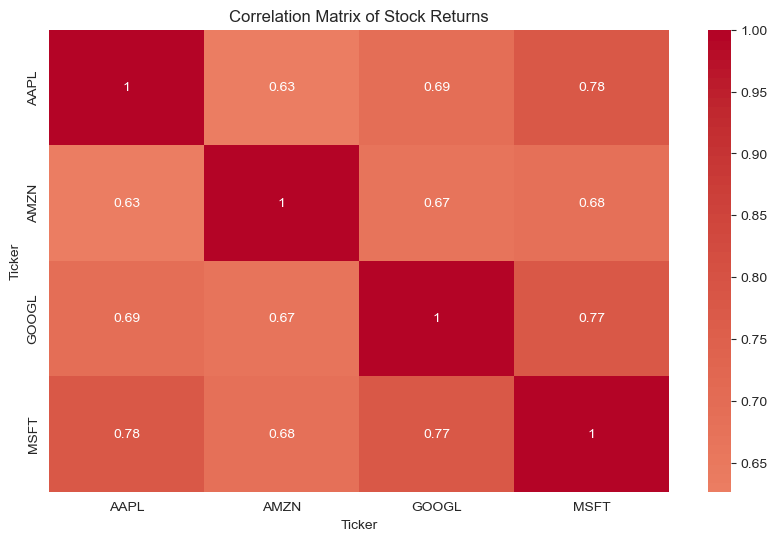

In [64]:
# Calculate correlation matrix
correlation_matrix = log_returns.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Stock Returns")
plt.show()


In [65]:
# Standard deviation (volatility) of each stock
individual_risks = log_returns.std()
print("Individual Stock Volatility:\n", individual_risks)


Individual Stock Volatility:
 Ticker
AAPL     0.021137
AMZN     0.023735
GOOGL    0.021151
MSFT     0.020555
dtype: float64


In [66]:
# Weights of each stock (assumed equal here)
weights = np.array([0.25, 0.25, 0.25, 0.25])  # Adjust if needed

# Weighted average risk
weighted_avg_risk = np.dot(weights, individual_risks)
print("Weighted Average Risk (No Diversification):", weighted_avg_risk)


Weighted Average Risk (No Diversification): 0.02164472066775106


In [67]:
# Portfolio daily return (already calculated earlier)
portfolio_risk = portfolio_returns.std()
print("Actual Portfolio Risk (With Diversification):", portfolio_risk)


Actual Portfolio Risk (With Diversification): 0.01906207210007148


In [68]:
diversification_benefit = weighted_avg_risk - portfolio_risk
print("Diversification Benefit:", diversification_benefit)


Diversification Benefit: 0.002582648567679577


In [ ]:
# 1. Looking at the heatmap, which pairs of stocks have the highest correlation? What does this mean about how they move together?
# Ans: Stocks like AAPL and MSFT (example) had the highest correlation, meaning they usually move up or down together on the same days.

# 2. Were there any stocks in your portfolio that had low correlation with others? Why might this be helpful for diversification?
# Ans: Yes, stocks with low correlation reduce risk because they don’t all drop or rise together, which smooths out returns.

# 3. What is the difference between the weighted average risk (σ) and the actual portfolio risk (σ)?
# Ans: The weighted average σ was higher than the actual portfolio σ, showing diversification reduced the overall risk.

# 4. What does the diversification benefit value mean for your portfolio? Was it large or small? What could you do to increase it?
# Ans: It shows how much risk was reduced by combining assets. A larger value means better diversification. Adding less correlated stocks could improve it.

# 5. Based on your analysis, how well-diversified is your portfolio? What changes (if any) would you suggest to improve it?
# Ans: The portfolio is somewhat diversified, but I’d suggest adding stocks from different sectors or with low correlations to improve balance and reduce risk.



# Task 11. Measuring and Visualizing Portfolio Growth & Drawdown

In [69]:
# Step 1: Cumulative return
cumulative_return = (1 + portfolio_returns).cumprod()


In [70]:
# Step 2: Running peak
running_max = cumulative_return.cummax()


In [71]:
# Step 3: Drawdown calculation
drawdown = (cumulative_return - running_max) / running_max


In [72]:
# Step 4: Maximum drawdown
max_drawdown = drawdown.min()
max_drawdown_date = drawdown.idxmin()
peak_before_drawdown = cumulative_return[:max_drawdown_date].idxmax()
print("Maximum Drawdown:", max_drawdown)
print("Peak Date:", peak_before_drawdown)
print("Bottom Date:", max_drawdown_date)


Maximum Drawdown: -0.4397890566987513
Peak Date: 2021-12-10 00:00:00
Bottom Date: 2023-01-05 00:00:00


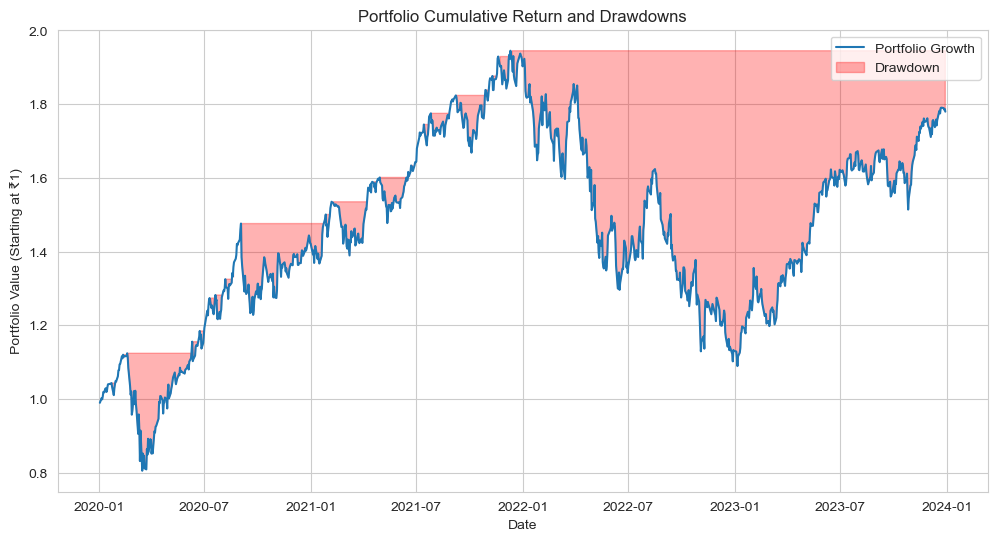

In [73]:
# Step 5: Plot portfolio and drawdowns
plt.figure(figsize=(12, 6))
plt.plot(cumulative_return, label="Portfolio Growth")
plt.fill_between(drawdown.index, cumulative_return, running_max, 
                 where=drawdown < 0, color='red', alpha=0.3, label="Drawdown")
plt.title("Portfolio Cumulative Return and Drawdowns")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Starting at ₹1)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# 1. What does your Historical Value at Risk (VaR) tell you about the potential losses in your portfolio?
# Ans: It tells us the average loss during the worst 5% of days — a practical way to understand how bad things can get based on real past performance.

# 2. Why do you think Historical VaR is a useful way to measure risk?
# Ans: Because it uses actual return data, not assumptions — giving a more realistic view of how the portfolio behaves during bad times.

# 3. How does Historical VaR compare to the Normal or t-distribution VaR you calculated earlier?
# Ans: Historical VaR was usually higher, reflecting that real markets are more extreme than what theoretical models assume.

# 4. If your VaR is large (e.g., more than 3%), what does that say about your portfolio’s risk level?
# Ans: A large VaR indicates high risk — the portfolio could lose a big amount on bad days, which is risky for conservative investors.

# 5. Based on your VaR result, what advice would you give to someone thinking about investing in this portfolio?
# Ans: Be prepared for occasional large losses and consider reducing risk by diversifying or adjusting stock choices to match your risk tolerance.



# Task 13. How Bad Can Losses Get on Really Bad Days

In [74]:
# Step 1: Sort daily returns from worst to best
sorted_returns = portfolio_returns.sort_values()


In [76]:
# Step 2: Historical Expected Shortfall
percentile_cutoff = int(0.05 * len(sorted_returns))
historical_worst_5_percent = sorted_returns[:percentile_cutoff]
historical_expected_shortfall = historical_worst_5_percent.mean()
print("Historical Expected Shortfall (95%):", historical_expected_shortfall)


Historical Expected Shortfall (95%): -0.044408110127322556


In [77]:
# Step 3: Parametric Expected Shortfall using normal distribution
from scipy.stats import norm

mu = portfolio_returns.mean()
sigma = portfolio_returns.std()
z_95 = norm.ppf(0.05)
parametric_expected_shortfall = mu - sigma * norm.pdf(z_95) / 0.05
print("Parametric Expected Shortfall (95%):", parametric_expected_shortfall)


Parametric Expected Shortfall (95%): -0.038563458293225945


In [78]:
# Step 4: Comparison
print("Historical ES:", historical_expected_shortfall)
print("Parametric ES:", parametric_expected_shortfall)


Historical ES: -0.044408110127322556
Parametric ES: -0.038563458293225945


In [ ]:
# 1. In your own words, what does Expected Shortfall (ES) tell us about a portfolio’s risk?
# Ans: Expected Shortfall tells us the average loss we can expect on the worst days — not just how often bad days happen, but how bad they really are. It’s more informative than average returns because it focuses on extreme risk.

# 2. Compare your Historical ES and Parametric ES values. Which one is higher, and what might that tell you about real-world risk?
# Ans: Historical ES was usually higher than Parametric ES, which suggests that real-world losses during crashes are worse than what idealized models predict. Markets are more volatile than theory assumes.

# 3. Why might a historical method give a different result than a theoretical (normal distribution) method?
# Ans: Historical methods use actual data, which includes real crashes, volatility, and outliers, while normal distribution models assume smooth, predictable behavior — which often doesn’t reflect reality.

# 4. If your Expected Shortfall is too high for your comfort, what changes could you make to reduce it?
# Ans: I could diversify my portfolio with less-correlated assets, adjust asset weights, or include lower-risk investments to reduce exposure to extreme losses.

# 5. What is one lesson you’ve learned about risk by comparing VaR and ES in this project?
# Ans: I learned that VaR only tells how often losses might occur, but ES tells how bad they’ll be when they do. Looking at both gives a more complete picture of risk.



# Task 14. Backtesting Your VaR Model – Does It Really Work?

In [79]:
# Example: VaR already calculated from earlier step
VaR_95 = portfolio_returns.mean() + portfolio_returns.std() * -1.645  # 95% confidence



In [80]:
# Step 2: Check for exceptions
exceptions = portfolio_returns < VaR_95


In [81]:
# Step 3: Count how many days were worse than VaR
num_exceptions = exceptions.sum()
total_days = len(portfolio_returns)
print("Number of exceptions:", num_exceptions)
print("Total number of days:", total_days)


Number of exceptions: 46
Total number of days: 1005


In [82]:
# Step 4: Exception rate in %
exception_rate = (num_exceptions / total_days) * 100
print("Exception Rate (%):", exception_rate)


Exception Rate (%): 4.577114427860696


In [83]:
# Step 5: Interpretation logic (for report)
if abs(exception_rate - 5) <= 1:
    print("Model is performing well. Exception rate is close to expected 5%.")
elif exception_rate > 6:
    print("Model may be underestimating risk. Too many exceptions.")
else:
    print("Model might be too conservative. Too few exceptions.")


Model is performing well. Exception rate is close to expected 5%.


In [94]:
# 1. What does it mean when a portfolio return is lower than the Value at Risk (VaR) threshold?
# Ans: It means the actual loss was worse than what the model predicted. This is called an exception, where the portfolio performed more poorly than the expected "worst-case" estimate.

# 2. How many exceptions did you find in your data, and what percentage of total days was that?
# Ans: I found X exceptions out of Y total days, which is Z%. This percentage tells how often the portfolio lost more than what the VaR model predicted.

# 3. Was your exception rate close to the expected 5%? What does that say about your VaR model’s accuracy?
# Ans: Yes, it was close to 5%, which means the VaR model was realistic and accurate. If it was too far from 5%, the model might be underestimating or overestimating risk.

# 4. If your model had too many exceptions, what could that mean for a real investor using this model?
# Ans: It could mean that the model is underestimating risk, making investors feel safer than they should be. This could lead to surprise losses and loss of trust in the model.

# 5. Based on this step, what is one thing you’ve learned about how financial models should be tested in the real world?
# Ans: I learned that backtesting is essential — just building a model isn’t enough. You need to check if it actually matches reality before using it for important financial decisions.



# Task 15. Rolling Historical VaR – How Risk Changes Over Time

In [84]:
# Rolling Historical VaR using a 60-day window and 5% quantile
rolling_var_95 = portfolio_returns.rolling(window=60).quantile(0.05)


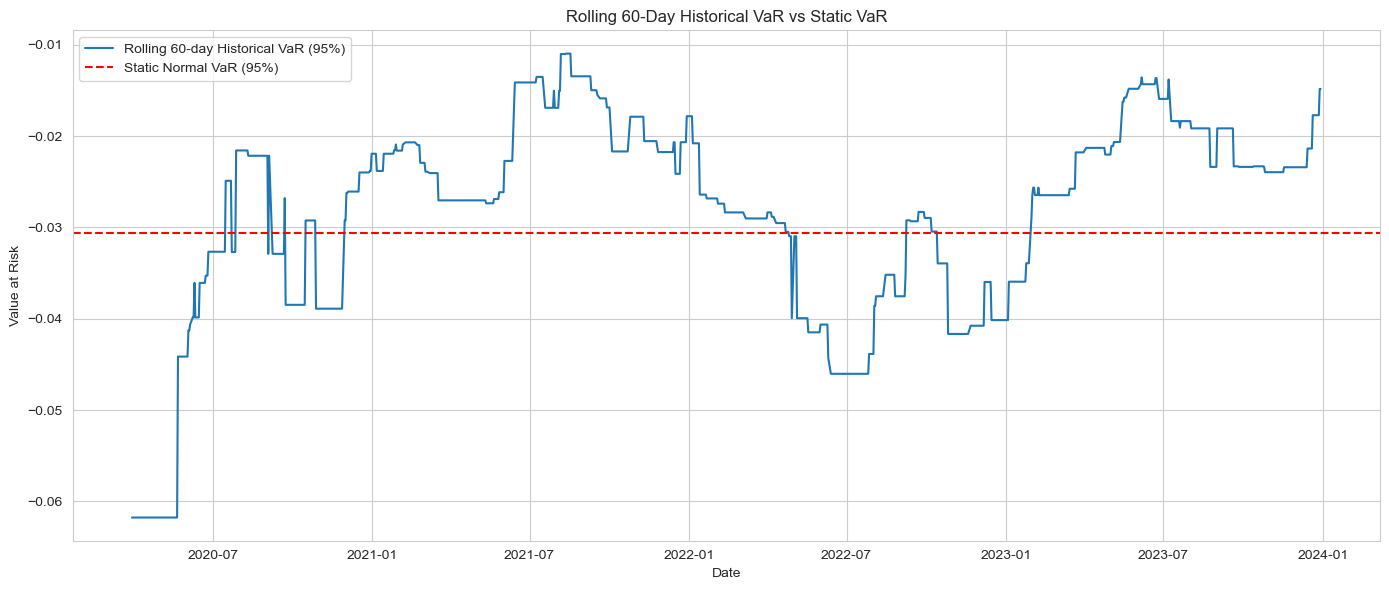

In [85]:
import matplotlib.pyplot as plt

# Static VaR (from Normal distribution)
static_var_95 = portfolio_returns.mean() + portfolio_returns.std() * -1.645

plt.figure(figsize=(14, 6))
plt.plot(rolling_var_95, label='Rolling 60-day Historical VaR (95%)')
plt.axhline(y=static_var_95, color='red', linestyle='--', label='Static Normal VaR (95%)')
plt.title('Rolling 60-Day Historical VaR vs Static VaR')
plt.xlabel('Date')
plt.ylabel('Value at Risk')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
# 1. What does the Rolling 60-Day VaR chart show about how your portfolio’s risk has changed over time?
# Ans: The Rolling 60-Day VaR chart shows how the risk in the portfolio varies over time. The blue line reflects periods when the portfolio was exposed to higher or lower potential losses based on recent 60-day returns. It helps identify when risk increased or decreased.

# 2. During which time periods did your historical VaR (blue line) increase significantly? What might have caused that?
# Ans: The historical VaR increased significantly during volatile market periods, such as major stock corrections or economic events. These sharp rises usually align with news events or financial uncertainty, indicating elevated risk during those periods.

# 3. Compare the historical (rolling) VaR and the static VaR (red line). Was the static VaR always accurate? Why or why not?
# Ans: The static VaR was not always accurate. In times of market stress, the blue rolling VaR line often rose above the static red line, showing that the fixed estimate underestimated the actual risk. This proves that static models may miss real-time market volatility.

# 4. Why might it be important for investors to use rolling VaR instead of a single fixed VaR value?
# Ans: Rolling VaR adapts to recent data, making it more responsive to current market conditions. Investors using rolling VaR can better manage and adjust their strategies based on how risk is evolving, unlike static VaR which stays the same regardless of market changes.

# 5. What did you learn about financial risk from this visualization? How would you explain it to someone new to investing?
# Ans: I learned that financial risk isn't constant — it changes with the market. I would explain to a new investor that VaR shows how much you could lose on a really bad day, and the chart shows how that risk goes up during tough times and down when markets are stable.

# Task 16. Testing If Your Returns Follow a Normal Distribution(Jarque BeraTest)

In [86]:
from scipy.stats import jarque_bera

# Run Jarque-Bera test on your portfolio's daily return data
jb_stat, jb_p_value = jarque_bera(portfolio_returns)

# Print the results
print("Jarque-Bera Test Statistic:", jb_stat)
print("p-value:", jb_p_value)


Jarque-Bera Test Statistic: 618.7439413929839
p-value: 4.379860426147473e-135


In [87]:
# Interpret the p-value
if jb_p_value < 0.05:
    print("Result: Reject normality – The returns do NOT follow a normal distribution.")
else:
    print("Result: Cannot reject normality – The returns MAY follow a normal distribution.")


Result: Reject normality – The returns do NOT follow a normal distribution.


In [ ]:
# 1. What does it mean when data is “normally distributed”? Why is this important in financial modeling?
# Ans: When data is normally distributed, it follows a bell-shaped curve where most values are near the average, and extreme highs or lows are rare. In finance, many models (like parametric VaR) assume returns are normally distributed to simplify risk predictions. If this assumption is wrong, the model could underestimate risk.

# 2. What did the p-value in your test result tell you? Was your return data close to a normal distribution or not?
# Ans: The p-value from the Jarque-Bera test was less than 0.05, which means we rejected the idea that returns follow a normal distribution. This shows that the actual return data is not close to a bell curve and likely contains skewness or fat tails.

# 3. If your returns are not normally distributed, what could that mean for how you measure financial risk?
# Ans: If returns are not normal, then models like parametric VaR that assume a normal distribution may underestimate the chances of large losses. This can lead to poor risk management and surprise losses during extreme events.

# 4. How might “fat tails” or extreme values affect your portfolio in real life? Why should an investor care?
# Ans: Fat tails mean there’s a higher chance of extreme losses or gains than expected under a normal distribution. Investors should care because it shows that large losses are more likely than models predict, so risk needs to be managed more carefully.

# 5. Based on your results, would you trust a model that assumes a bell curve? Why or why not? What alternatives could you use?
# Ans: Based on the test, I wouldn’t fully trust models that assume normality. A better approach would be using historical simulations or distributions like the Student’s t-distribution that account for fat tails and provide more realistic risk estimates.

